In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [7]:
data = datasets.load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names
print(target_names)



['setosa' 'versicolor' 'virginica']


In [8]:
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df["target"] = y

iris_df["species"] = [target_names[i] for i in y]
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


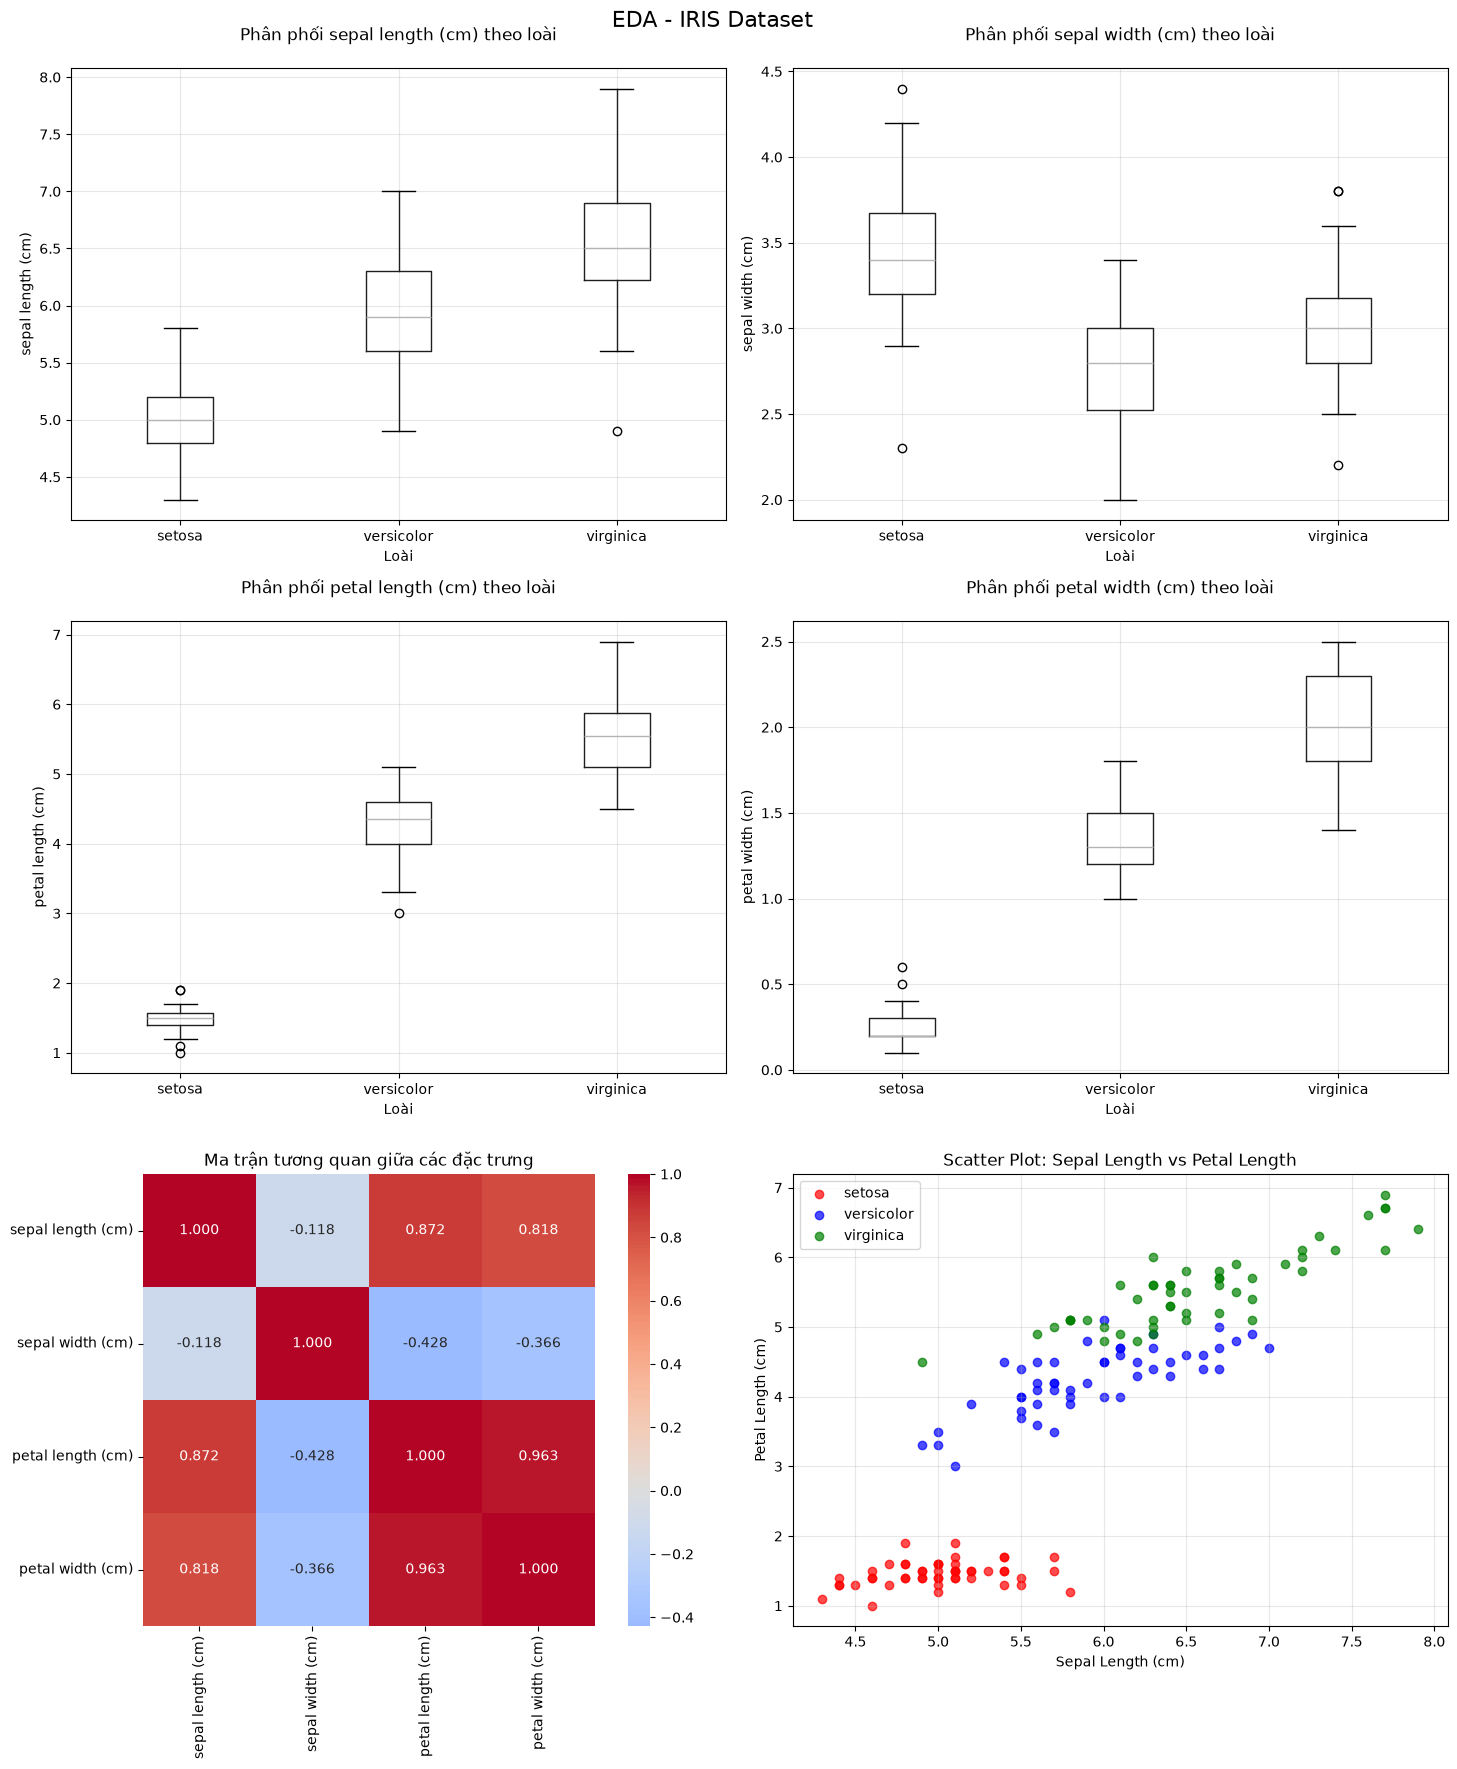

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
# 1. Phân phối các đặc trưng theo loài
for i, feature in enumerate(feature_names):
    ax = axes[i//2, i%2]
    iris_df.boxplot(column=feature, by="species", ax=ax)
    ax.set_title(f"Phân phối {feature} theo loài", fontsize=12, pad=20)
    ax.set_xlabel("Loài", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(True, alpha=0.3)

# 2. Ma trận tương quan
axes[2, 0].remove()
axes[2, 0] = plt.subplot(3, 2, 5)
correlation_matrix = iris_df[feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, square=True, ax=axes[2, 0], fmt=".3f")
axes[2, 0].set_title("Ma trận tương quan giữa các đặc trưng", fontsize=12)

# 3. Scatter plot
axes[2, 1].remove()
axes[2, 1] = plt.subplot(3, 2, 6)
colors = ["red", "blue", "green"]
for i, species in enumerate(target_names):
    species_data = iris_df[iris_df["species"] == species]
    axes[2, 1].scatter(species_data["sepal length (cm)"],
    species_data["petal length (cm)"],  
    label=species, alpha=0.7, color=colors[i])
    axes[2, 1].set_xlabel("Sepal Length (cm)", fontsize=10)
    axes[2, 1].set_ylabel("Petal Length (cm)", fontsize=10)
    axes[2, 1].set_title("Scatter Plot: Sepal Length vs Petal Length",fontsize=12)
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

plt.suptitle("EDA - IRIS Dataset", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("01_EDA_IRIS.png", dpi=600, bbox_inches="tight")
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y: chia deu target


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [11]:
max_depth = 5
min_samples_split = 10

dt_classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
dt_classifier.fit(X_train, y_train)

pred = dt_classifier.predict(X_test)

print(classification_report(y_test, pred, target_names=target_names))

print(y_test)
print(pred)
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy:.4f} ")

train_pred = dt_classifier.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, pred)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)



              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Accuracy: 0.9667 
Train accuracy: 0.9833333333333333
Test accuracy: 0.9666666666666667
